In [ ]:
install.packages(c("tm", "SnowballC", "syuzhet", "tidyverse", "wordcloud", "ggplot2"))

library(tm)
library(SnowballC)
library(syuzhet)
library(tidyverse)
library(wordcloud)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: NLP

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ ggplot2::annotate() masks NLP::annotate()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: RColorBrewer



In [ ]:
# Reading in data
data <- read.csv("/content/tripadvisor.csv", header = TRUE)
# Check structure of csv file
str(data)

Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“EOF within quoted string”


'data.frame':	8219 obs. of  3 variables:
 $ S.No. : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Review: chr  "nice hotel expensive parking got good deal stay hotel anniversary \tarrived late evening took advice previous r"| __truncated__ "ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle \tstart booked suit"| __truncated__ "nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranea"| __truncated__ "unique \tgreat stay \twonderful time hotel monaco \tlocation excellent short stroll main downtown shopping area"| __truncated__ ...
 $ Rating: int  4 2 3 5 5 5 5 4 5 5 ...


In [ ]:
# Convert review column of dataframe to character vector
corpus <- iconv(data$Review, to = "UTF-8", sub = "byte")
# Create corpus from character vector above
corpus <- Corpus(VectorSource(corpus))
# Inspect first five rows
inspect(corpus[1:5])

<<SimpleCorpus>>
Metadata:  corpus specific: 1, document level (indexed): 0
Content:  documents: 5

[1] nice hotel expensive parking got good deal stay hotel anniversary \tarrived late evening took advice previous reviews did valet parking \tcheck quick easy \tlittle disappointed non-existent view room room clean nice size \tbed comfortable woke stiff neck high pillows \tnot soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway \tmaybe just noisy neighbors \taveda bath products nice \tdid not goldfish stay nice touch taken advantage staying longer \tlocation great walking distance shopping \toverall nice experience having pay 40 parking night \t                                                                                                                                                                                                                                                                                                     

In [ ]:
# Convert the text to lower case
cleaned_corpus <- tm_map(corpus, content_transformer(tolower))
# Remove punctuation
cleaned_corpus <- tm_map(cleaned_corpus, removePunctuation)
# Remove numbers
cleaned_corpus <- tm_map(cleaned_corpus, removeNumbers)
# Remove common English stopwords
cleaned_corpus <- tm_map(cleaned_corpus, removeWords, stopwords('english'))
# Remove extra whitespaces
cleaned_corpus <- tm_map(cleaned_corpus, stripWhitespace)
# Reduce words to their root form (stemming)
cleaned_corpus <- tm_map(cleaned_corpus, stemDocument)

# Inspect first five rows after cleaning
inspect(cleaned_corpus[1:5])

Warning message in tm_map.SimpleCorpus(corpus, content_transformer(tolower)):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_corpus, removePunctuation):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_corpus, removeNumbers):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_corpus, removeWords, stopwords("english")):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_corpus, stripWhitespace):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_corpus, stemDocument):
“transformation drops documents”


<<SimpleCorpus>>
Metadata:  corpus specific: 1, document level (indexed): 0
Content:  documents: 5

[1] nice hotel expens park got good deal stay hotel anniversari arriv late even took advic previous review valet park check quick easi littl disappoint nonexist view room room clean nice size bed comfort woke stiff neck high pillow soundproof like heard music room night morn loud bang door open close hear peopl talk hallway mayb just noisi neighbor aveda bath product nice goldfish stay nice touch taken advantag stay longer locat great walk distanc shop overal nice experi pay park night                                                                                                                                                                                                                                                                                                                                                                                                                          

In [ ]:
# Sample a subset of the data
set.seed(123)  # for reproducibility
sampled_reviews <- sample(data$Review, 200)  # adjust the sample size as needed
sampled_corpus <- Corpus(VectorSource(iconv(sampled_reviews, to = "UTF-8", sub = "byte")))

In [ ]:
# Clean the sampled corpus
cleaned_sampled_corpus <- tm_map(sampled_corpus, content_transformer(tolower))
cleaned_sampled_corpus <- tm_map(cleaned_sampled_corpus, removePunctuation)
cleaned_sampled_corpus <- tm_map(cleaned_sampled_corpus, removeNumbers)
cleaned_sampled_corpus <- tm_map(cleaned_sampled_corpus, removeWords,
                                 stopwords('english'))
cleaned_sampled_corpus <- tm_map(cleaned_sampled_corpus, stripWhitespace)
cleaned_sampled_corpus <- tm_map(cleaned_sampled_corpus, stemDocument)

Warning message in tm_map.SimpleCorpus(sampled_corpus, content_transformer(tolower)):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_sampled_corpus, removePunctuation):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_sampled_corpus, removeNumbers):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_sampled_corpus, removeWords, stopwords("english")):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_sampled_corpus, stripWhitespace):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(cleaned_sampled_corpus, stemDocument):
“transformation drops documents”


In [ ]:
# Create sparse term document matrix
tdm_sparse <- TermDocumentMatrix(cleaned_sampled_corpus,
                                 control = list(weighting = weightTfIdf))
tdm_m_sparse <- as.matrix(tdm_sparse)

Warning message in TermDocumentMatrix.SimpleCorpus(cleaned_sampled_corpus, control = list(weighting = weightTfIdf)):
“custom functions are ignored”


In [ ]:
# Show frequency of terms
term_freq <- rowSums(tdm_m_sparse)
term_freq_sorted <- sort(term_freq, decreasing = TRUE)
tdm_d_sparse <- data.frame(word = names(term_freq_sorted), freq = term_freq_sorted)
# Show top 5 most frequent words
head(tdm_d_sparse, 5)

,word,freq
,<chr>,<dbl>
great,great,2.609237
hotel,hotel,2.471301
nice,nice,2.380467
locat,locat,2.374865
good,good,2.195289


In [ ]:
text <- iconv(data$Review)

syuzhet_vector <- get_sentiment(text, method = "syuzhet")
cat("Syuzhet method",head(syuzhet_vector),"\n")

bing_vector <- get_sentiment(text, method = "bing")
cat("Bing method:",head(bing_vector),"\n")

afinn_vector <- get_sentiment(text, method = "afinn")
cat("Afinn method:",head(afinn_vector),"\n")

Syuzhet method 3.25 10.7 5.1 8.75 6.3 12.2 
Bing method: 3 11 5 9 7 7 
Afinn method: 14 28 5 21 15 23 


In [ ]:
# Compare first row of each vector (sign function creates common scale)
rbind(
  sign(head(syuzhet_vector)),
  sign(head(bing_vector)),
  sign(head(afinn_vector))
)

1,1,1,1,1,1
1,1,1,1,1,1
1,1,1,1,1,1


Warning message in wordcloud(words = tdm_d_sparse$word, freq = tdm_d_sparse$freq, :
“night could not be fit on page. It will not be plotted.”
Warning message in wordcloud(words = tdm_d_sparse$word, freq = tdm_d_sparse$freq, :
“avenida could not be fit on page. It will not be plotted.”
Warning message in wordcloud(words = tdm_d_sparse$word, freq = tdm_d_sparse$freq, :
“staff could not be fit on page. It will not be plotted.”
Warning message in wordcloud(words = tdm_d_sparse$word, freq = tdm_d_sparse$freq, :
“breakfast could not be fit on page. It will not be plotted.”
Warning message in wordcloud(words = tdm_d_sparse$word, freq = tdm_d_sparse$freq, :
“close could not be fit on page. It will not be plotted.”
Warning message in wordcloud(words = tdm_d_sparse$word, freq = tdm_d_sparse$freq, :
“clean could not be fit on page. It will not be plotted.”
Warning message in wordcloud(words = tdm_d_sparse$word, freq = tdm_d_sparse$freq, :
“comfort could not be fit on page. It will not be plotted.

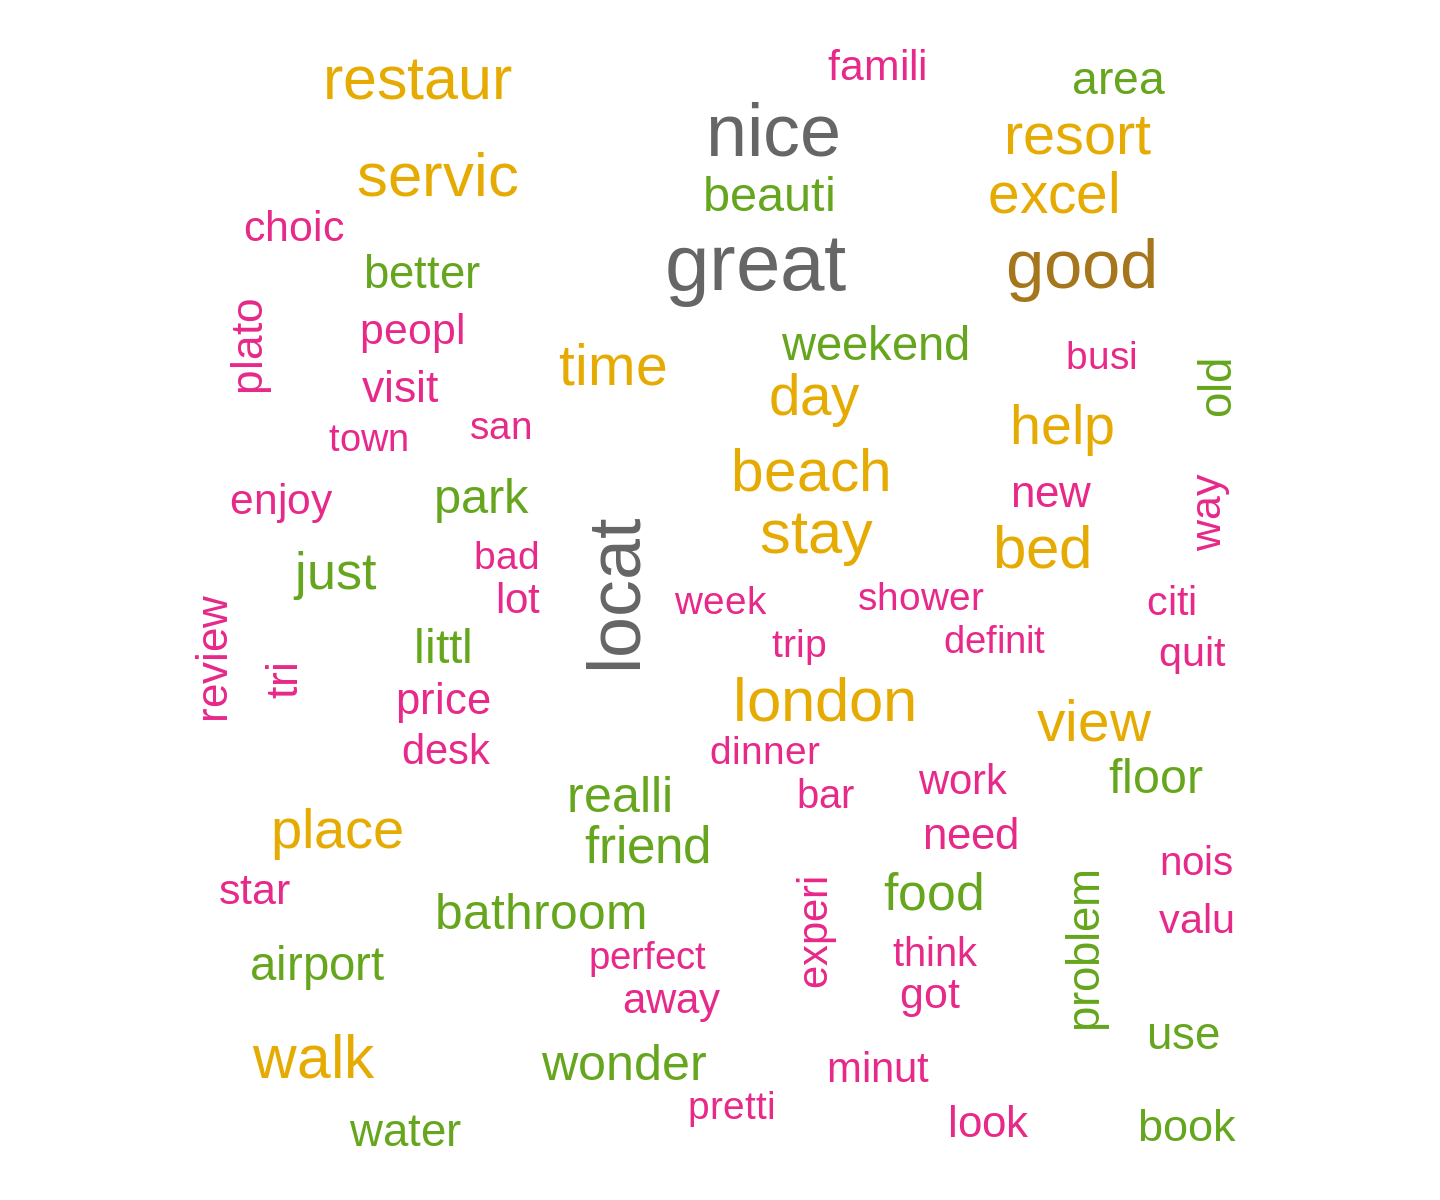

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 10)

wordcloud(words = tdm_d_sparse$word, freq = tdm_d_sparse$freq,
          min.freq = 10, max.words = 100, colors = brewer.pal(8, "Dark2"))

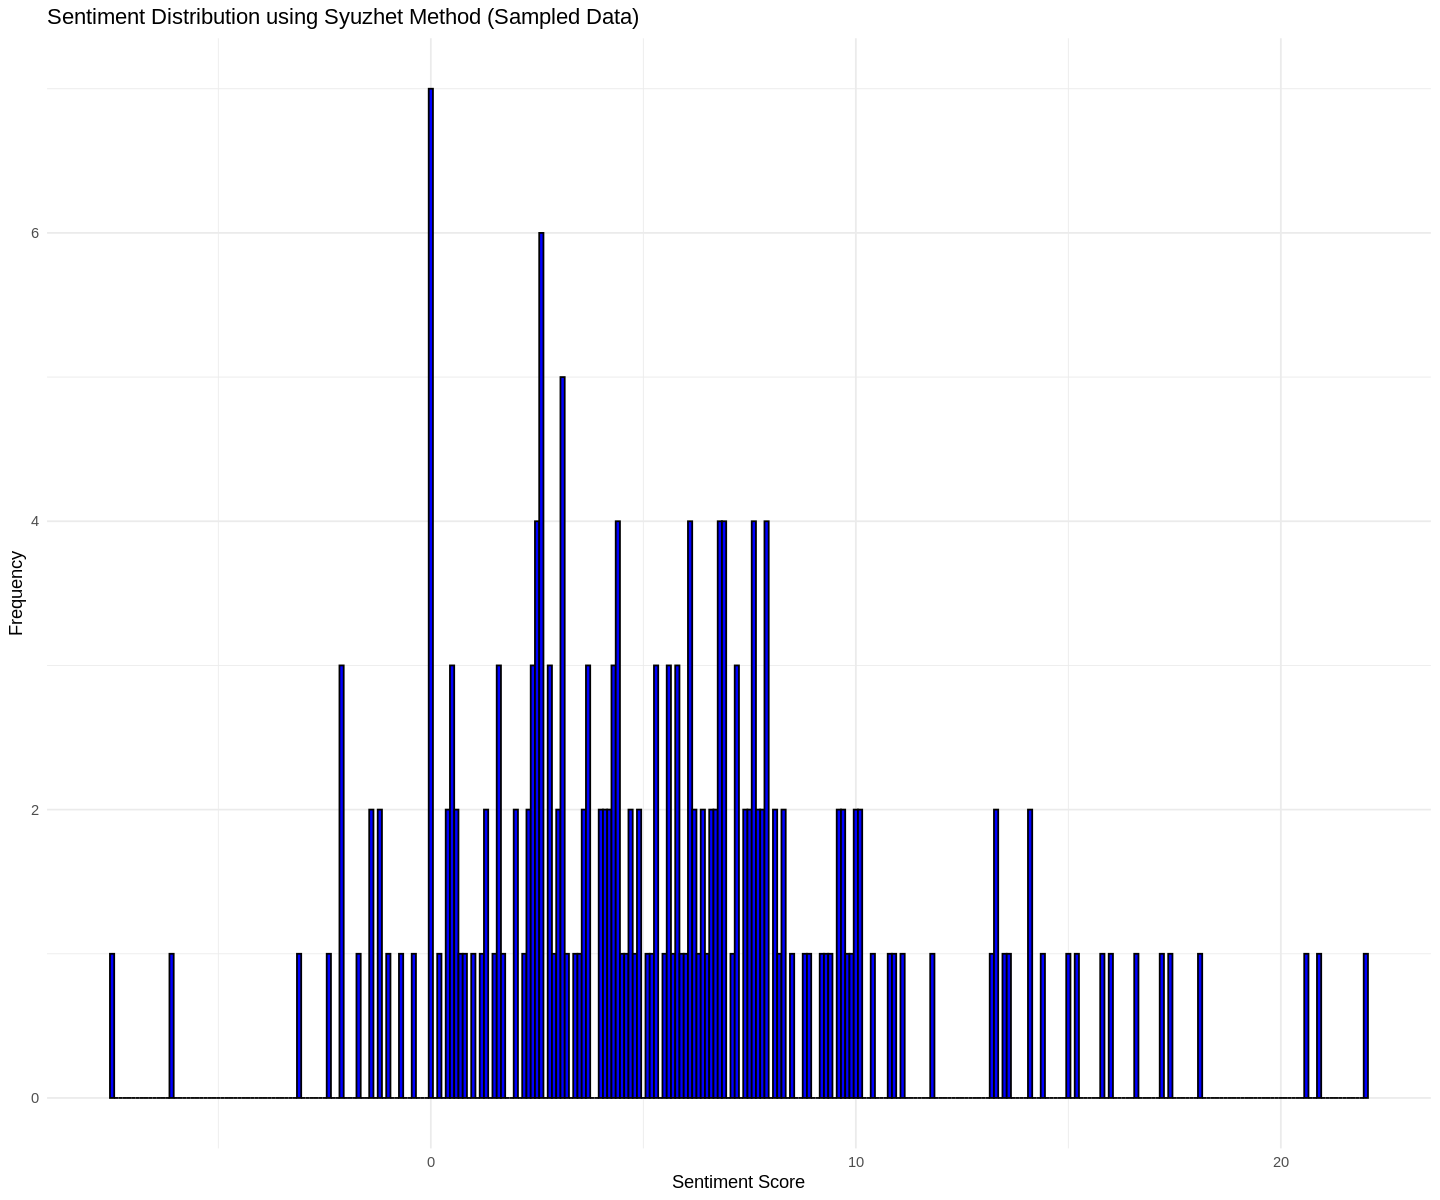

In [ ]:
# Using the full dataset for sentiment analysis might still
text_sampled <- iconv(sampled_reviews)
syuzhet_vector_sampled <- get_sentiment(text_sampled, method = "syuzhet")

ggplot(data.frame(syuzhet_vector_sampled), aes(x = syuzhet_vector_sampled)) +
  geom_histogram(binwidth = 0.1, fill = "blue", color = "black") +
  labs(title = "Sentiment Distribution using Syuzhet Method (Sampled Data)",
       x = "Sentiment Score", y = "Frequency") +
  theme_minimal()

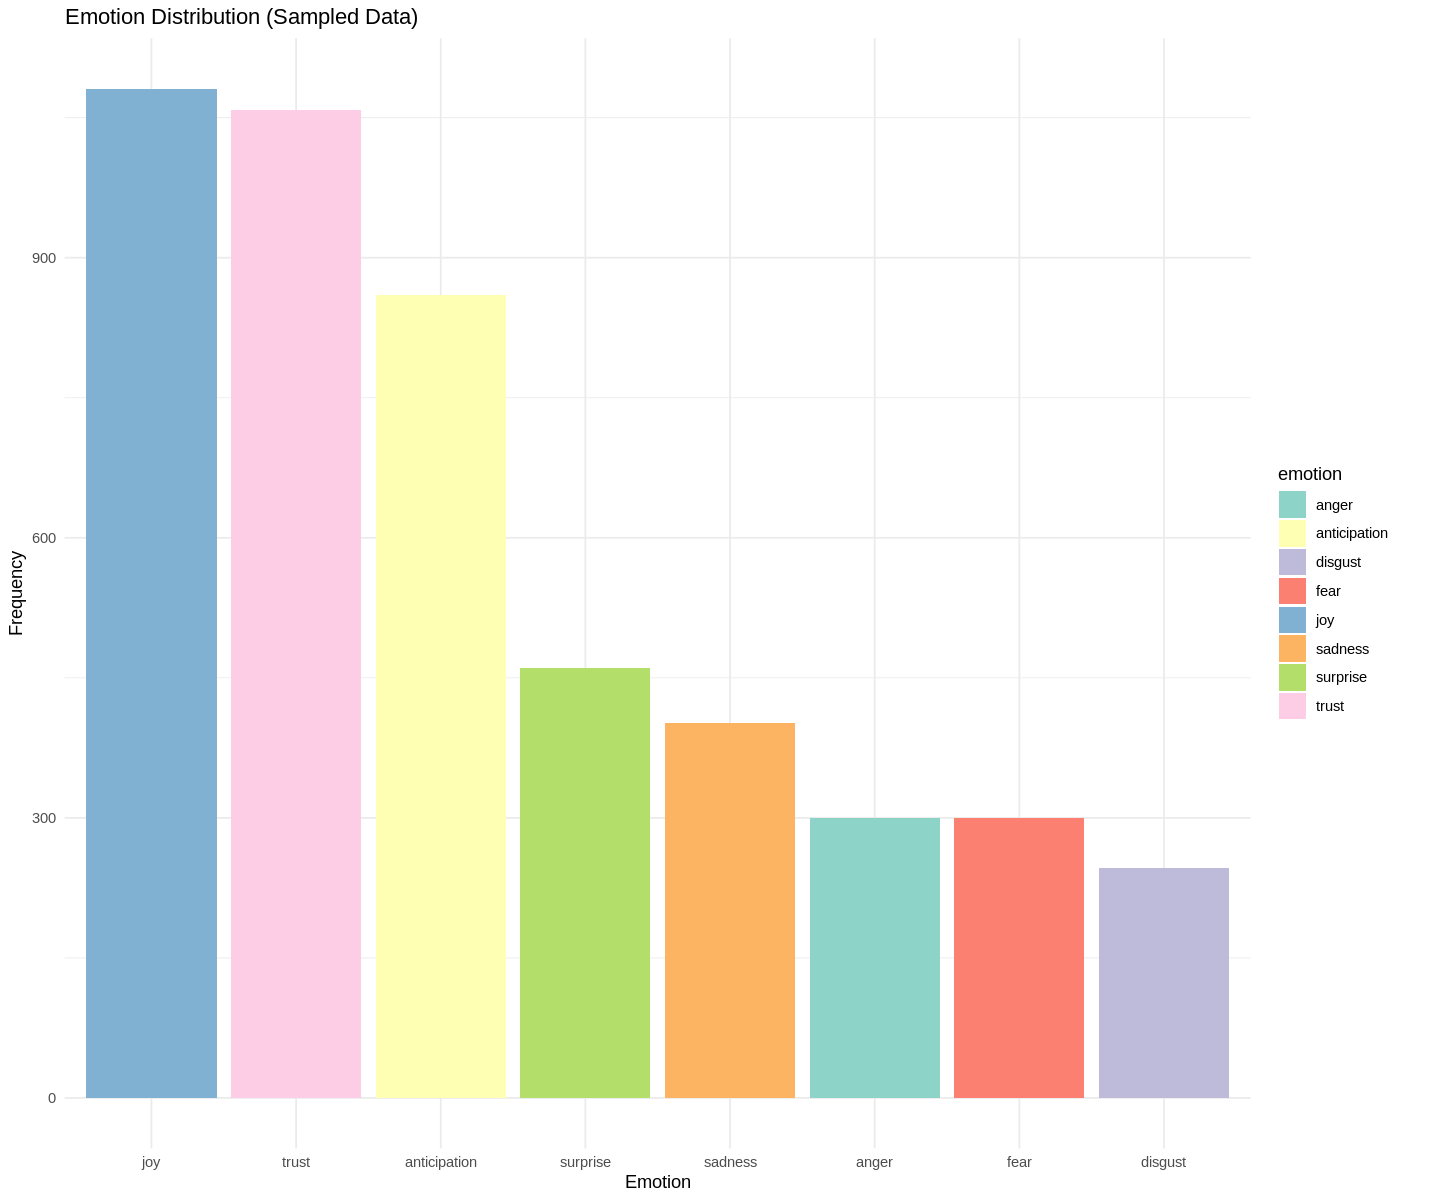

In [ ]:
nrc_sampled <- get_nrc_sentiment(text_sampled)
nrct_sampled <- data.frame(t(nrc_sampled))
nrcs_sampled <- data.frame(rowSums(nrct_sampled))
nrcs_sampled <- cbind("sentiment" = rownames(nrcs_sampled), nrcs_sampled)
rownames(nrcs_sampled) <- NULL
names(nrcs_sampled)[1] <- "sentiment"
names(nrcs_sampled)[2] <- "frequency"
nrcs_sampled <- nrcs_sampled %>% mutate(percent = frequency/sum(frequency))
nrcs2_sampled <- nrcs_sampled[1:8, ]
colnames(nrcs2_sampled)[1] <- "emotion"

ggplot(nrcs2_sampled, aes(x = reorder(emotion, -frequency), y = frequency,
                          fill = emotion)) +
  geom_bar(stat = "identity") +
  labs(title = "Emotion Distribution (Sampled Data)", x = "Emotion", y = "Frequency") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set3")

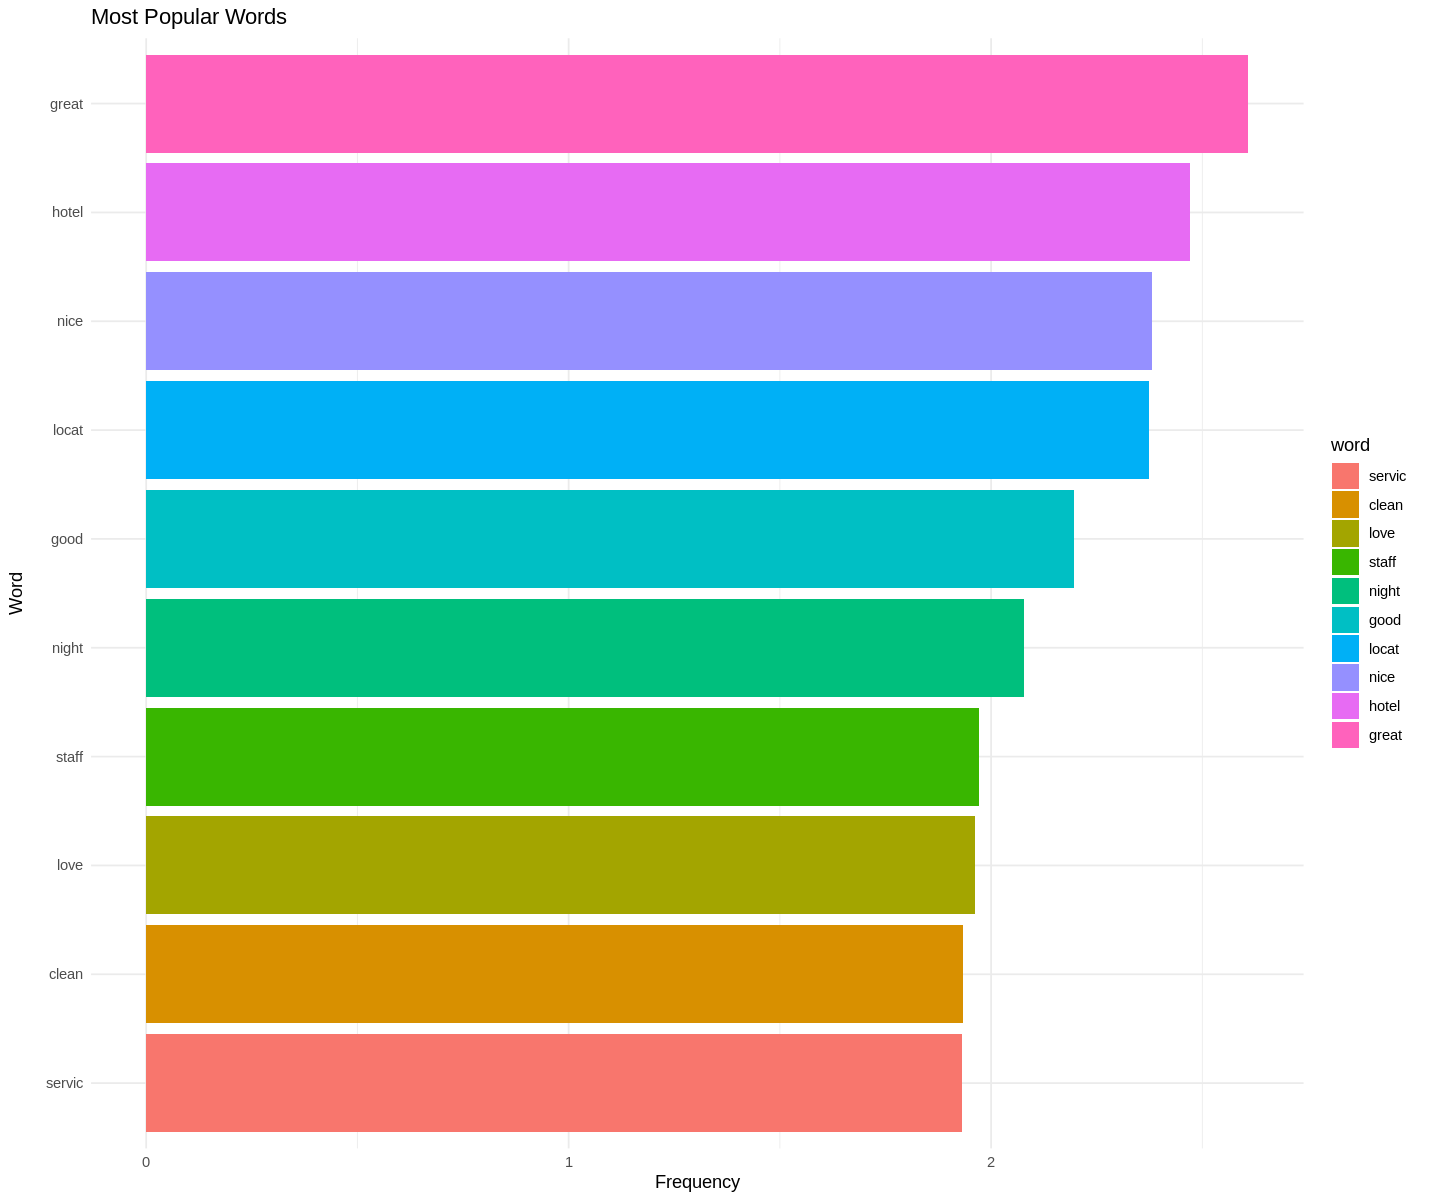

In [ ]:
#bar plot of most popular words

tdm_d_sparse <- tdm_d_sparse[1:10, ]
tdm_d_sparse$word <- reorder(tdm_d_sparse$word, tdm_d_sparse$freq)
ggplot(tdm_d_sparse, aes(x = word, y = freq, fill = word)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Most Popular Words", x = "Word", y = "Frequency") +
  theme_minimal()

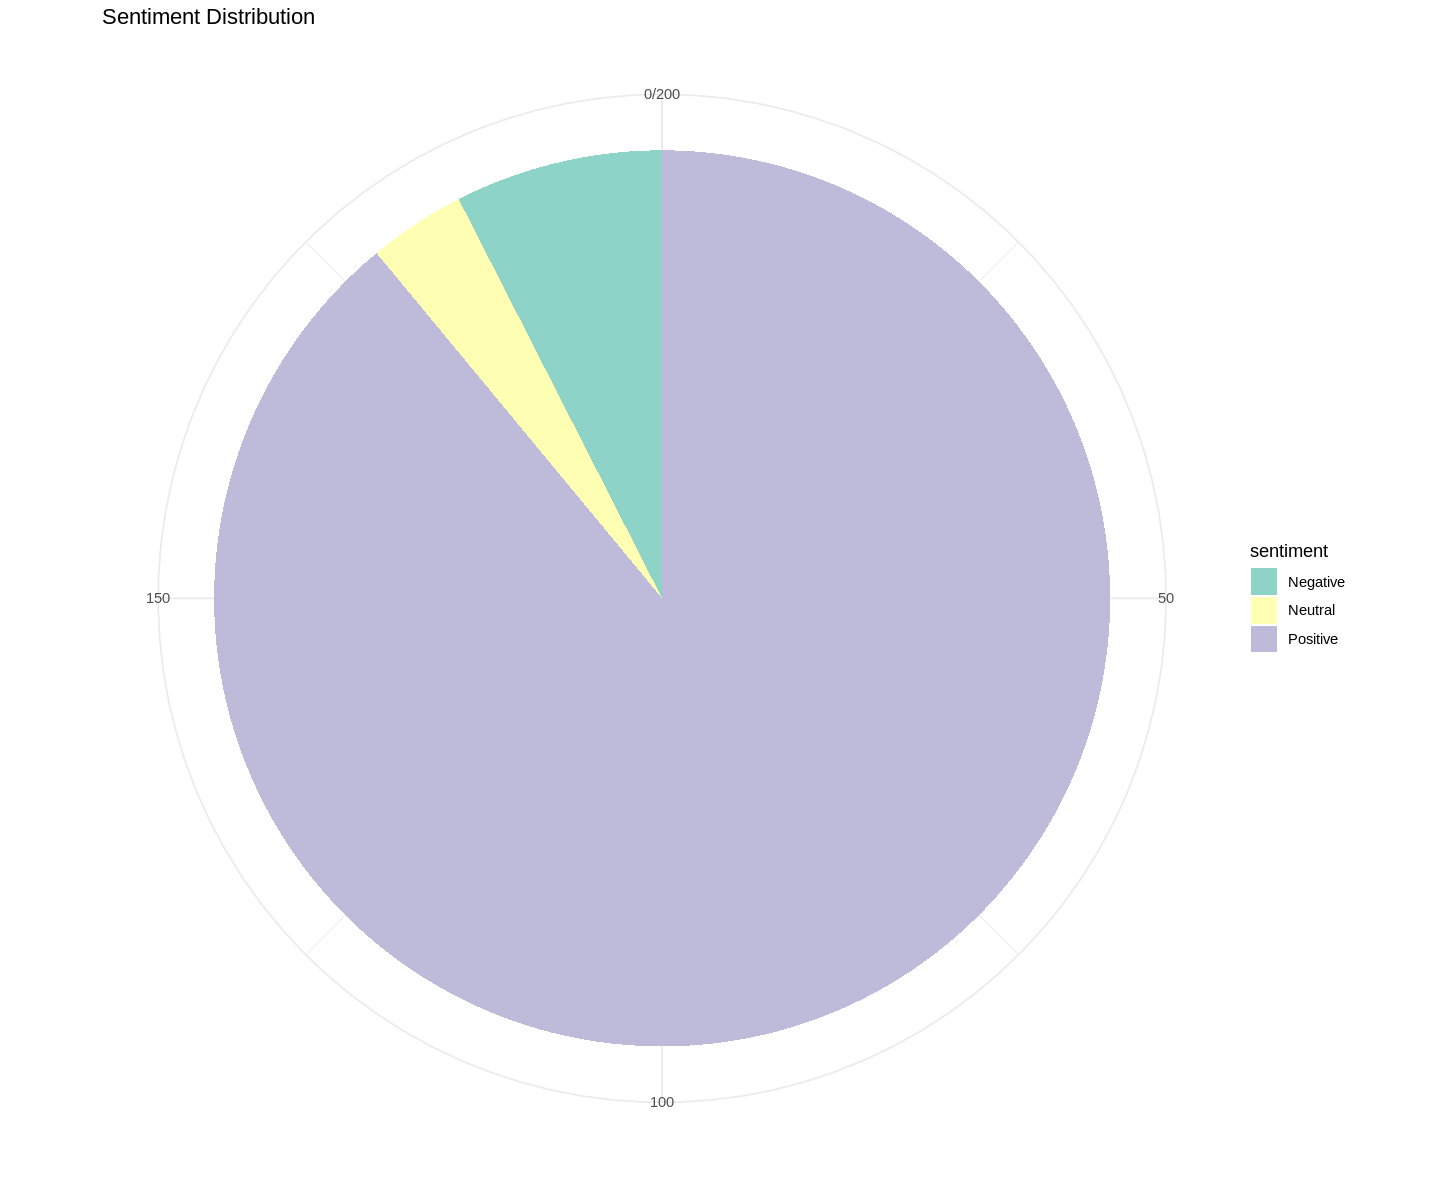

In [ ]:
#Pie Chart of Sentiment Distribution

library(ggplot2)
library(RColorBrewer)

# Create a data frame with sentiment and count
sentiment_df <- data.frame(
  sentiment = c("Positive", "Negative", "Neutral"),
  count = c(sum(syuzhet_vector_sampled > 0), sum(syuzhet_vector_sampled < 0),
            sum(syuzhet_vector_sampled == 0))
)

# Create a pie chart
ggplot(sentiment_df, aes(x = "", y = count, fill = sentiment)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title = "Sentiment Distribution", x = "", y = "") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set3")